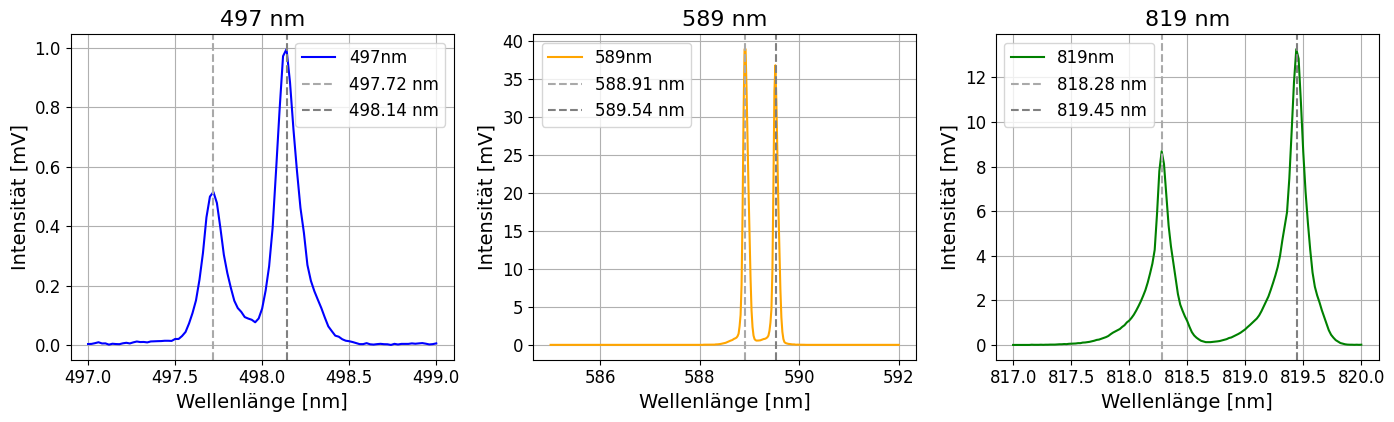

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv('csv/Aufgabe1_497.csv')
df.columns = df.columns.str.replace('"', '').str.strip()
df_1 = pd.read_csv('csv/Aufgabe1_589.csv')
df_1.columns = df_1.columns.str.replace('"', '').str.strip()
df_2 = pd.read_csv('csv/Aufgabe1_819.csv')
df_2.columns = df_2.columns.str.replace('"', '').str.strip()
df_3 = pd.read_csv('csv/Peak_test.csv')
df_3.columns = df_3.columns.str.replace('"', '').str.strip()

# Plot für a_x
fig, axs = plt.subplots(1, 3, figsize=(14, 4.5))
#fig.suptitle("Lichtstärke über die Wellenlänge für alle Messungen", fontsize=18, y=0.97)

axs[0].plot(df['Wellenlänge [nm]'], df['Intensität [mV]'], label="497nm", color="blue")
axs[0].set_xlabel("Wellenlänge [nm]", fontsize=14)
axs[0].set_ylabel("Intensität [mV]", fontsize=14)
axs[0].set_title("497 nm", fontsize=16)
axs[0].grid(True)
axs[0].axvline(497.72, color='darkgray', linestyle='--', label='497.72 nm')
axs[0].axvline(498.14, color='gray', linestyle='--', label='498.14 nm')
axs[0].legend(fontsize=12)
axs[0].tick_params(axis='both', labelsize=12)

axs[1].plot(df_1['Wellenlänge [nm]'], df_1['Intensität [mV]'], label="589nm", color="orange")
axs[1].set_xlabel("Wellenlänge [nm]", fontsize=14)
axs[1].set_ylabel("Intensität [mV]", fontsize=14)
axs[1].set_title("589 nm", fontsize=16)
axs[1].grid(True)
axs[1].axvline(588.91, color='darkgray', linestyle='--', label='588.91 nm')
axs[1].axvline(589.54, color='gray', linestyle='--', label='589.54 nm')
axs[1].legend(fontsize=12)
axs[1].tick_params(axis='both', labelsize=12)

axs[2].plot(df_2['Wellenlänge [nm]'], df_2['Intensität [mV]'], label="819nm", color="green")
axs[2].set_xlabel("Wellenlänge [nm]", fontsize=14)
axs[2].set_ylabel("Intensität [mV]", fontsize=14)
axs[2].set_title("819 nm", fontsize=16)
axs[2].grid(True)
axs[2].axvline(818.28, color='darkgray', linestyle='--', label='818.28 nm')
axs[2].axvline(819.45, color='gray', linestyle='--', label='819.45 nm')
axs[2].legend(fontsize=12)
axs[2].tick_params(axis='both', labelsize=12)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
# Plot für Peak_test
# plt.figure(figsize=(10, 4))
# plt.plot(df_3['Wellenlänge [nm]'], df_3['Intensität [mV]'], label="Lichtstärke", color="red")
# plt.xlabel("Wellenlänge [nm]")
# plt.ylabel("Intensität [mV]")
# plt.title("Lichtstärke über die Wellenlänge")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()
# Save the figure to PDF (use fig.savefig to avoid blank output)
fig.savefig('plot_aufgabe_1.pdf', format='pdf', bbox_inches='tight')


In [3]:
def compute_fwhm(wl, inten):
    wl = np.asarray(wl)
    y = np.asarray(inten)
    # find local maxima
    peaks = np.where((y[1:-1] > y[:-2]) & (y[1:-1] > y[2:]))[0] + 1
    baseline = np.nanmin(y)
    results = []
    for p in peaks:
        peak_y = y[p]
        half = (peak_y + baseline) / 2.0

        # left crossing
        i = p
        while i > 0 and y[i] > half:
            i -= 1
        if i == p:  # no left drop found
            left_wl = wl[0]
        else:
            y0, y1 = y[i], y[i + 1]
            x0, x1 = wl[i], wl[i + 1]
            if y1 == y0:
                left_wl = x0
            else:
                left_wl = x0 + (half - y0) * (x1 - x0) / (y1 - y0)

        # right crossing
        j = p
        while j < len(y) - 1 and y[j] > half:
            j += 1
        if j == p:  # no right drop found
            right_wl = wl[-1]
        else:
            y0, y1 = y[j - 1], y[j]
            x0, x1 = wl[j - 1], wl[j]
            if y1 == y0:
                right_wl = x1
            else:
                right_wl = x0 + (half - y0) * (x1 - x0) / (y1 - y0)

        fwhm = right_wl - left_wl
        results.append({
            "peak_index": int(p),
            "peak_wavelength": float(wl[p]),
            "peak_intensity": float(peak_y),
            "left_half_max_wl": float(left_wl),
            "right_half_max_wl": float(right_wl),
            "fwhm": float(fwhm)
        })
    return results

datasets = [("497 nm", df), ("589 nm", df_1), ("819 nm", df_2)]
for name, data in datasets:
    wl = data['Wellenlänge [nm]']
    inten = data['Intensität [mV]']
    res = compute_fwhm(wl, inten)
    if not res:
        print(f"{name}: no peaks found")
    else:
        for r in res:
            print(f"{name} - peak @ {r['peak_wavelength']:.3f} nm, intensity {r['peak_intensity']:.3f} mV, FWHM = {r['fwhm']:.3f} nm")


497 nm - peak @ 497.060 nm, intensity 0.009 mV, FWHM = 0.075 nm
497 nm - peak @ 497.100 nm, intensity 0.005 mV, FWHM = 0.128 nm
497 nm - peak @ 497.140 nm, intensity 0.004 mV, FWHM = 1.497 nm
497 nm - peak @ 497.220 nm, intensity 0.007 mV, FWHM = 1.368 nm
497 nm - peak @ 497.280 nm, intensity 0.012 mV, FWHM = 1.299 nm
497 nm - peak @ 497.320 nm, intensity 0.010 mV, FWHM = 1.307 nm
497 nm - peak @ 497.720 nm, intensity 0.515 mV, FWHM = 0.146 nm
497 nm - peak @ 498.140 nm, intensity 0.996 mV, FWHM = 0.143 nm
497 nm - peak @ 498.600 nm, intensity 0.006 mV, FWHM = 0.034 nm
497 nm - peak @ 498.680 nm, intensity 0.004 mV, FWHM = 0.075 nm
497 nm - peak @ 498.760 nm, intensity 0.004 mV, FWHM = 0.027 nm
497 nm - peak @ 498.860 nm, intensity 0.005 mV, FWHM = 0.162 nm
497 nm - peak @ 498.920 nm, intensity 0.006 mV, FWHM = 0.153 nm
589 nm - peak @ 585.720 nm, intensity 0.000 mV, FWHM = 0.020 nm
589 nm - peak @ 586.380 nm, intensity 0.000 mV, FWHM = 0.020 nm
589 nm - peak @ 587.340 nm, intensity 0.